# Setting up HugginFace - Importing basics and Login.

In [193]:
import os
HF_TOKEN = os.getenv("HF_TOKEN")

In [194]:
from huggingface_hub import login
login(token=HF_TOKEN)

In [195]:
!hf auth whoami

78891.87s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


user:  RonnieSDas


"https://huggingface.co/spaces/mrdbourke/trashify_demo_v4" - Final Project Demo looks like the one below:

In [196]:
from IPython.display import HTML 

HTML("""
<iframe
    src="https://mrdbourke-trashify-demo-v4.hf.space"
    frameborder="0"
    width="850"
    height="1150"
></iframe>
""")

In [202]:
import datasets
import gradio as gr
import torchmetrics 
import pycocotools
import random
import numpy as np
import torch
import transformers
from pprint import pprint


#Check package versions:
print(f"USING VERSIONS - \ttransformers : {transformers.__version__}, \t datasets : {datasets.__version__}, \t torch : {torch.__version__}, \t torchmetrics : {torchmetrics.__version__}")

USING VERSIONS - 	transformers : 5.2.0, 	 datasets : 4.5.0, 	 torch : 2.5.1+cu121, 	 torchmetrics : 1.8.2


NOTE: A tool for drawing boxes on images for object boundary detection is [Prodigy](https://prodi.gy/features/computer-vision)

# Loading the dataset

In [204]:
from datasets import load_dataset
load_dataset? #Basic class definition

SyntaxError: invalid syntax (4313301.py, line 2)

In [205]:
dataset = load_dataset(path = "mrdbourke/trashify_manual_labelled_images")
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 1128
    })
})

In [206]:
print(dataset['train']) # type(dataset) -> datasets.dataset_dict.DatasetDict | isinstance(dataset, datasets.dataset_dict.DatasetDict) -> True
type(dataset)

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
})


datasets.dataset_dict.DatasetDict

In [304]:
# Understanding the datatype of the dataset and how to access it. Comment and execute to see specific parts
print(dataset['train'], type(dataset['train']), '\n')

pprint(dataset['train'].features)
print("type of dataset['train'].features ", type(dataset['train'].features), '\n')

pprint(dataset['train'].features['annotations'])
print("type of dataset['train'].features['annotations'] ", type(dataset['train'].features['annotations']), '\n')

pprint(dataset['train'].features['annotations']['category_id'])
print("type of dataset['train'].features['annotations']['category_id'] ", type(dataset['train'].features['annotations']['category_id']), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature)
print("type of dataset['train'].features['annotations']['category_id'].feature ", type(dataset['train'].features['annotations']['category_id'].feature), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature.names)
print("type of dataset['train'].features['annotations']['category_id'].feature.names ", type(dataset['train'].features['annotations']['category_id'].feature.names), '\n')

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
}) <class 'datasets.arrow_dataset.Dataset'> 

{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}
type of dataset['train'].features  <class 'datasets.features.features.Features'> 

{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Valu

In [207]:
pprint(dataset['train'][0]) #Viewing a sample's features

{'annotations': {'area': [135381.078125, 1039532.4375],
                 'bbox': [[523.7000122070312,
                           545.0999755859375,
                           402.79998779296875,
                           336.1000061035156],
                          [10.399999618530273,
                           163.6999969482422,
                           943.4000244140625,
                           1101.9000244140625]],
                 'category_id': [1, 0],
                 'file_name': ['00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg',
                               '00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg'],
                 'image_id': [292, 292],
                 'iscrowd': [0, 0]},
 'image': <PIL.Image.Image image mode=RGB size=960x1280 at 0x7B00E584C320>,
 'image_id': 292,
 'image_source': 'manual_taken_photo',
 'label_source': 'manual_prodigy_label'}


In [208]:
print(type(dataset['train'].features))
pprint(dataset['train'].features) #Viewing all samples' features

<class 'datasets.features.features.Features'>
{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}


In [209]:
print(type(dataset['train'].features['annotations']))
pprint(dataset['train'].features['annotations']) # Accessing a specific key in the 'dataset["train"]' dict.
print('\n', type(dataset['train'].features['annotations'])) # Turns out each key is a dict as well. A nested dict structure.
print('\n', dataset['train'].features['annotations'].keys()) # Set of all keys inside the dict 'annotations' which happens to be a key of the dict 'dataset['train']'
print('\n', dataset['train'].features['annotations']['area']) # Accessing a specific key in the 'annotations' dict.

<class 'dict'>
{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Value('string')),
 'image_id': List(Value('int64')),
 'iscrowd': List(Value('int64'))}

 <class 'dict'>

 dict_keys(['file_name', 'image_id', 'category_id', 'bbox', 'iscrowd', 'area'])

 List(Value('float32'))


In [210]:
dataset['train'][2]['annotations']['bbox'][0] # This array gives us the coordinates of a single bounding box in the format XYWH.

[349.5, 677.2000122070312, 210.89999389648438, 376.0]

X is the x-coordinate of the top left corner of the box (349.5). \
Y is the y-coordinate of the top left corner of the box (677.2000122070312).\
W is the width of the box (210.89999389648438).\
H is the height of the box (376.0).

In [211]:
categories = dataset['train'].features['annotations']['category_id']
print(type(categories), dir(categories), "\n")
print(type(categories.feature), "\n")
print(categories)
print(categories.feature)
print(categories.feature.names)

<class 'datasets.features.features.List'> ['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_type', 'feature', 'id', 'length', 'pa_type'] 

<class 'datasets.features.features.ClassLabel'> 

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])
['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']


In [212]:
# Creating a mapping from numbers to labels
id2label = {i:class_name for i, class_name in enumerate(categories.feature.names)}
print(id2label.items())
label2id = {value:key for key, value in id2label.items()}
print(label2id.items())

dict_items([(0, 'bin'), (1, 'hand'), (2, 'not_bin'), (3, 'not_hand'), (4, 'not_trash'), (5, 'trash'), (6, 'trash_arm')])
dict_items([('bin', 0), ('hand', 1), ('not_bin', 2), ('not_hand', 3), ('not_trash', 4), ('trash', 5), ('trash_arm', 6)])


In [213]:
# Creating a colour palette
# Make colour dictionary
colour_palette = {
    'bin': (0, 0, 224),         # Bright Blue (High contrast with greenery) in format (red, green, blue)
    'not_bin': (255, 80, 80),   # Light Red to indicate negative class

    'hand': (148, 0, 211),      # Dark Purple (Contrasts well with skin tones)
    'not_hand': (255, 80, 80),  # Light Red to indicate negative class

    'trash': (0, 255, 0),       # Bright Green (For trash-related items)
    'not_trash': (255, 80, 80), # Light Red to indicate negative class

    'trash_arm': (255, 140, 0), # Deep Orange (Highly visible)
}

pprint(colour_palette)

{'bin': (0, 0, 224),
 'hand': (148, 0, 211),
 'not_bin': (255, 80, 80),
 'not_hand': (255, 80, 80),
 'not_trash': (255, 80, 80),
 'trash': (0, 255, 0),
 'trash_arm': (255, 140, 0)}


We’ll just have to write a small function to normalize our colour values from [0, 255] to [0, 1] \
 (matplotlib expects our colour values to be between 0 and 1).


[('bin', (0.0, 0.0, 0.8784313725490196)),
 ('not_bin', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('hand', (0.5803921568627451, 0.0, 0.8274509803921568)),
 ('not_hand', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash', (0.0, 1.0, 0.0)),
 ('not_trash', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash_arm', (1.0, 0.5490196078431373, 0.0))]

 <class 'list'>


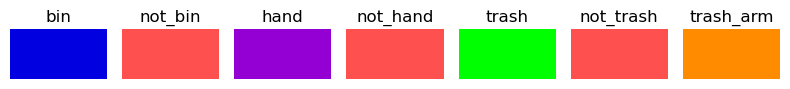

In [214]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize RGB values between 0-1 range:
def normalize_rgb(rgb_tuple):
    return tuple(x/255 for x in rgb_tuple)

# Turn colors into normalized RGB values for matplotlib
colors_and_labels_rgb  = [(key, normalize_rgb(value)) for (key, value) in colour_palette.items()]
pprint(colors_and_labels_rgb) 
print('\n',type(colors_and_labels_rgb))

# Create figure and axis
fig, ax = plt.subplots(1, 7, figsize = (8,1))

# Flatten the axis array for easier iteration
ax = ax.flatten()

# Plot each color square
for idx, (label, color) in enumerate(colors_and_labels_rgb):
    ax[idx].add_patch(plt.Rectangle(xy=(0, 0), 
                                    width=1, 
                                    height=1, 
                                    facecolor=color))
    ax[idx].set_title(label)
    ax[idx].set_xlim(0, 1)
    ax[idx].set_ylim(0, 1)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()

# Plotting an image from the loaded dataset and visualizing the bounding boxes

In [215]:
# To make the images fit in the notebook window, it is important to create a function to make them smaller

import PIL

def half_image(image: PIL.Image) -> PIL.Image:
    """
    Resizes a given input image by half and returns the smaller version.
    """
    return image.resize(size=(image.size[0] // 2, image.size[1] // 2))

def half_boxes(boxes):
    """
    Halves an array/tensor of input boxes and returns them. Necessary for plotting them on a half-sized image.

    For example:

    boxes = [100, 100, 100, 100]
    half_boxes = half_boxes(boxes)
    print(half_boxes)

    >>> [50, 50, 50, 50]
    """
    if isinstance(boxes, list):
        # If boxes are list of lists, then we have multiple boxes
        for box in boxes:
            if isinstance(box, list):
                return [[coordinate // 2 for coordinate in box] for box in boxes]
            else:
                return [coordinate // 2 for coordinate in boxes]         
    
    if isinstance(boxes, np.ndarray):
        return (boxes // 2)
    
    if isinstance(boxes, torch.Tensor):
        return (boxes // 2)

# Test the functions 
image_test = dataset["train"][42]["image"]
image_test_half = half_image(image_test)
print(f"[INFO] Original image size: {image_test.size} | Half image size: {image_test_half.size}")

boxes_test_list = [100, 100, 100, 100]
print(f"[INFO] Original boxes: {boxes_test_list} | Half boxes: {half_boxes(boxes_test_list)}")

boxes_test_torch = torch.tensor([100.0, 100.0, 100.0, 100.0])
print(f"[INFO] Original boxes: {boxes_test_torch} | Half boxes: {half_boxes(boxes_test_torch)}")


[INFO] Original image size: (960, 1280) | Half image size: (480, 640)
[INFO] Original boxes: [100, 100, 100, 100] | Half boxes: [50, 50, 50, 50]
[INFO] Original boxes: tensor([100., 100., 100., 100.]) | Half boxes: tensor([50., 50., 50., 50.])


Plotting boxes on a single image step by step

[INFO] Showing training sample from index: 924 - 
Boxes in XYWH format: tensor([[178., 303., 119., 162.],
        [252., 334., 137., 125.],
        [ 98., 234., 225., 257.],
        [  2., 220., 130., 216.],
        [141., 115., 157.,  91.]])
Boxes in XYXY format: tensor([[178., 303., 297., 465.],
        [252., 334., 389., 459.],
        [ 98., 234., 323., 491.],
        [  2., 220., 132., 436.],
        [141., 115., 298., 206.]])

Label names: ['trash', 'hand', 'bin', 'bin', 'not_trash']
Colour codes: [(0, 255, 0), (148, 0, 211), (0, 0, 224), (0, 0, 224), (255, 80, 80)]


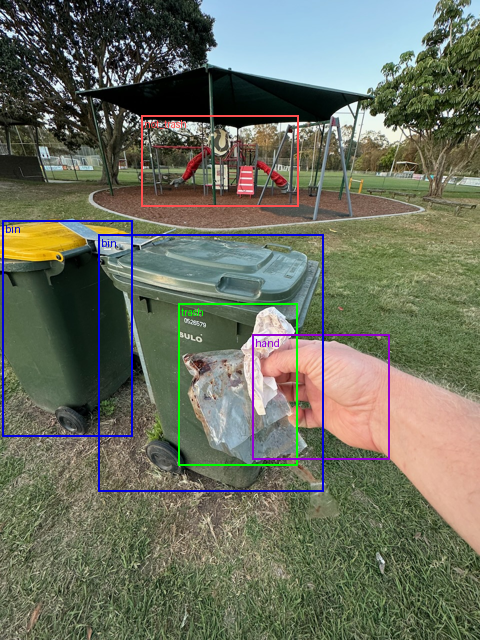

In [310]:
import random
import torch
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import pil_to_tensor, to_pil_image

# Step 1 : Select a random sample from the loaded dataset
random_index = random.randint(0, len(dataset['train']))
random_sample = dataset['train'][random_index]
print(f"[INFO] Showing training sample from index: {random_index} - ")

# Step 2 : Get image and boxes from random_sample
random_sample_image = random_sample['image']
random_sample_boxes = random_sample['annotations']['bbox']  
# Optional: Half the image and boxes for space saving (all of the following code will work with/without half size images)
half_random_sample_image = half_image(random_sample_image)
half_random_sample_boxes = half_boxes(random_sample_boxes)

# Step 3. Turn box coordinates in a tensor
boxes_xywh = torch.tensor(half_random_sample_boxes)
print(f"Boxes in XYWH format: {boxes_xywh}")

# Step 4. Convert coordinates from XYWH to XYXY (since torchvision.utils.draw_bounding_boxes requires input boxes in XYXY format (X_min, y_min, X_max, y_max))
boxes_xyxy = box_convert(boxes = boxes_xywh, in_fmt = 'xywh', out_fmt = 'xyxy')
print(f"Boxes in XYXY format: {boxes_xyxy}\n")

# Step 5. Get label names of target boxes and colours to match
random_sample_label_names = [categories.feature.names[x] for x in random_sample["annotations"]["category_id"]] 
random_sample_colours = [colour_palette[label] for label in random_sample_label_names]
print(f"Label names: {random_sample_label_names}")
print(f"Colour codes: {random_sample_colours}")

# Step 6. Converting half_random_sample_image from pil to tensor in order to use draw_bounding_boxes, then after the boxes are drawn on the image, using to_pil_image to plot the image with the bboxes drawn on it
to_pil_image(
    pic = draw_bounding_boxes(
        image = pil_to_tensor(pic = half_random_sample_image),
        boxes = boxes_xyxy,
        colors = random_sample_colours,
        labels = random_sample_label_names,
        width = 2,
        # label_colors = random_sample_colours
    )
)


In [ ]:
# Re-Understanding the datatype of the dataset and how to access it.
print(dataset['train'], type(dataset['train']), '\n')

pprint(dataset['train'].features)
print("type of dataset['train'].features ", type(dataset['train'].features), '\n')

pprint(dataset['train'].features['annotations'])
print("type of dataset['train'].features['annotations'] ", type(dataset['train'].features['annotations']), '\n')

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
}) <class 'datasets.arrow_dataset.Dataset'> 

{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}
type of dataset['train'].features  <class 'datasets.features.features.Features'> 

{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Valu

In [302]:
pprint(dataset['train'].features['annotations']['category_id'])
print("type of dataset['train'].features['annotations']['category_id'] ", type(dataset['train'].features['annotations']['category_id']), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature)
print("type of dataset['train'].features['annotations']['category_id'].feature ", type(dataset['train'].features['annotations']['category_id'].feature), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature.names)
print("type of dataset['train'].features['annotations']['category_id'].feature.names ", type(dataset['train'].features['annotations']['category_id'].feature.names), '\n')

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
type of dataset['train'].features['annotations']['category_id']  <class 'datasets.features.features.List'> 

ClassLabel(names=['bin',
                  'hand',
                  'not_bin',
                  'not_hand',
                  'not_trash',
                  'trash',
                  'trash_arm'])
type of dataset['train'].features['annotations']['category_id'].feature  <class 'datasets.features.features.ClassLabel'> 

['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']
type of dataset['train'].features['annotations']['category_id'].feature.names  <class 'list'> 



# Creating the model

In [321]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.modules.module")  # turn off warnings for loading the model (feel free to comment this if you want to see the warnings)

from transformers import AutoModelForObjectDetection
# help(AutoModelForObjectDetection)

MODEL_NAME = "PekingU/rtdetr_v2_r50vd"

model = AutoModelForObjectDetection.from_pretrained(
    pretrained_model_name_or_path = MODEL_NAME,
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = True     # Original model was trained with a different number of output classes to ours
                                       # So we'll ignore any mismatched sizes (e.g. 91 vs. 7)
)

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoisi

In [322]:
model

RTDetrV2ForObjectDetection(
  (model): RTDetrV2Model(
    (backbone): RTDetrV2ConvEncoder(
      (model): RTDetrResNetBackbone(
        (embedder): RTDetrResNetEmbeddings(
          (embedder): Sequential(
            (0): RTDetrResNetConvLayer(
              (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (1): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (2): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
          )
          (pooler)

In [323]:
type(model)

transformers.models.rt_detr_v2.modeling_rt_detr_v2.RTDetrV2ForObjectDetection

In [ ]:
print(f"[INFO] Final classification layer: {model.class_embed}\n") # 7 output classes
print(f"[INFO] Final box regression layer: {model.bbox_embed}") # 4 boundary box coordinates

[INFO] Final classification layer: ModuleList(
  (0-5): 6 x Linear(in_features=256, out_features=7, bias=True)
)

[INFO] Final box regression layer: ModuleList(
  (0-5): 6 x RTDetrV2MLPPredictionHead(
    (layers): ModuleList(
      (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
      (2): Linear(in_features=256, out_features=4, bias=True)
    )
  )
)
